In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Scikit-learn for CPU-based CART model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder



# Set plot style
plt.style.use('ggplot')

# Load the dataset
# The dataset uses semicolons as separators
df = pd.read_csv('/mnt/c/Users/sudee/Desktop/work/Enhancing-CART-with-a-K-Means-and-Random-Forest-Ensemble-for-Robust-Segmentation/bank+marketing/bank/bank-full.csv', sep=';')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
print("Starting data cleaning and preprocessing...")

# Drop the 'duration' column as recommended for a realistic model
df_cleaned = df.drop('duration', axis=1)
print("Dropped 'duration' column.")

# Convert target variable 'y' to binary (0 for 'no', 1 for 'yes')
df_cleaned['y'] = df_cleaned['y'].map({'no': 0, 'yes': 1})

# Separate features (X) and target (y)
X = df_cleaned.drop('y', axis=1)
y = df_cleaned['y']

# One-hot encode all categorical features
# This will automatically handle columns with text data
X_encoded = pd.get_dummies(X, drop_first=True)
print("Categorical features have been one-hot encoded.")
print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after encoding: {X_encoded.shape[1]}")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData has been split into training and testing sets.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Starting data cleaning and preprocessing...
Dropped 'duration' column.
Categorical features have been one-hot encoded.
Original number of features: 15
Number of features after encoding: 41

Data has been split into training and testing sets.
Training set shape: (36168, 41)
Testing set shape: (9043, 41)


--- Training CART Model on CPU ---
Training the model...
Model training complete.

--- CPU Model Evaluation ---
Accuracy: 0.7959

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.83      0.88      7985
         Yes       0.30      0.56      0.39      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.69      0.63      9043
weighted avg       0.86      0.80      0.82      9043

Confusion Matrix:


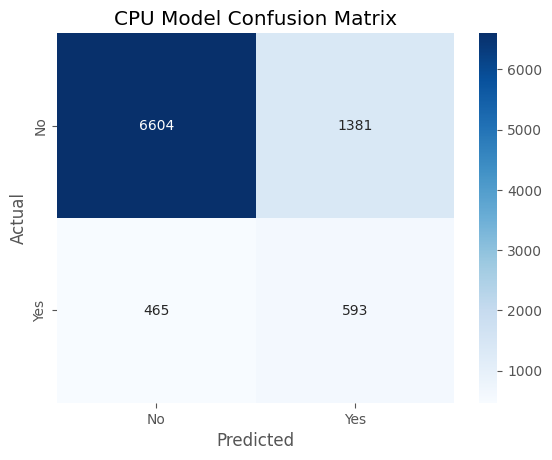

In [3]:
# --- Training CART Model on CPU ---
print("--- Training CART Model on CPU ---")

# Initialize the Decision Tree Classifier (CART)
cart_cpu = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')

# Train the model
print("Training the model...")
cart_cpu.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_cpu = cart_cpu.predict(X_test)

# --- Evaluate the Model ---
print("\n--- CPU Model Evaluation ---")

# Calculate accuracy
accuracy_cpu = accuracy_score(y_test, y_pred_cpu)
print(f"Accuracy: {accuracy_cpu:.4f}")

# Display the classification report for detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cpu, target_names=['No', 'Yes']))

# Display the confusion matrix
print("Confusion Matrix:")
cm_cpu = confusion_matrix(y_test, y_pred_cpu)
sns.heatmap(cm_cpu, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CPU Model Confusion Matrix')
plt.show()  

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Define the parameter grid for the CART model (no n_estimators)
cart_param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# 2. Initialize and run the Grid Search for the Decision Tree
cart_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=cart_param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1
)

print("Starting Grid Search for the CART model...")
cart_grid_search.fit(X_train, y_train)

# 3. Print the best parameters found for the CART model
print(f"\nBest parameters for CART model: {cart_grid_search.best_params_}")

Starting Grid Search for the CART model...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters for CART model: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}


Training the final, optimized CART model...
Training complete.

--- Final Optimized CART Model Evaluation ---
              precision    recall  f1-score   support

          No       0.94      0.85      0.89      7985
         Yes       0.34      0.57      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.71      0.66      9043
weighted avg       0.87      0.82      0.84      9043


Confusion Matrix:


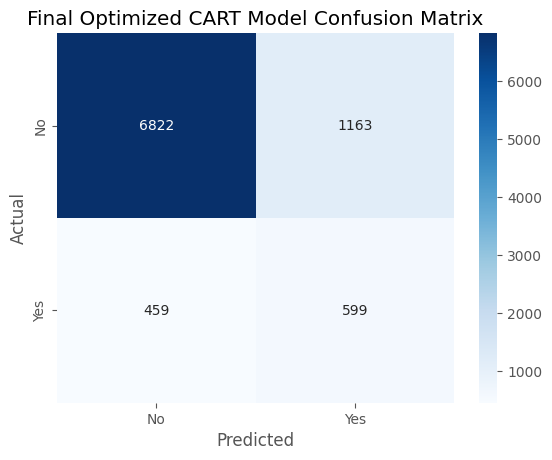

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the final CART model with the BEST parameters found
final_cart_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # Keep this for the imbalanced data
)

# Train the final model on the full training dataset
print("Training the final, optimized CART model...")
final_cart_model.fit(X_train, y_train)
print("Training complete.")

# Evaluate the final model on the test set
y_pred_final = final_cart_model.predict(X_test)

print("\n--- Final Optimized CART Model Evaluation ---")
print(classification_report(y_test, y_pred_final, target_names=['No', 'Yes']))


# --- ADDED: Display the confusion matrix ---
print("\nConfusion Matrix:")
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Optimized CART Model Confusion Matrix')
plt.show()

In [6]:
# Review 2 final code

--- Training Random Forest Model ---
Training the model...
Model training complete.

--- Random Forest Model Evaluation ---
Accuracy: 0.8949

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.67      0.20      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.59      0.63      9043
weighted avg       0.88      0.89      0.87      9043

Confusion Matrix:


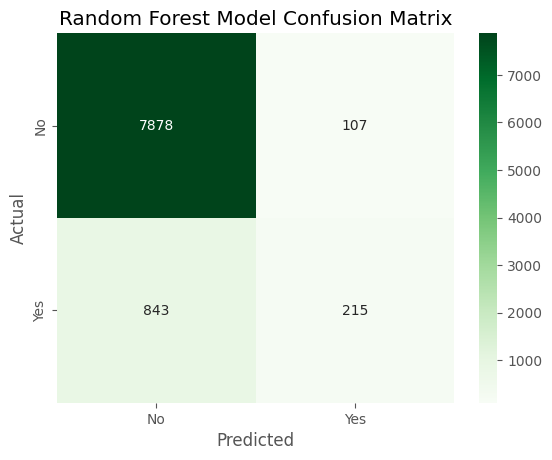

In [7]:
# %%
# --- Imports for Random Forest ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Training the Random Forest Model ---
print("--- Training Random Forest Model ---")

# Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
# class_weight='balanced' is useful for imbalanced datasets like this one
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# Train the model
print("Training the model...")
rf_model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# --- Evaluate the Model ---
print("\n--- Random Forest Model Evaluation ---")

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

# Display the confusion matrix
print("Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Model Confusion Matrix')
plt.show()

Starting Grid Search for the Random Forest model...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.8s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.8s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.8s
[CV] END max_depth=10, min_samples_leaf=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=10, n_estimators=200; total time=   0.8s
[CV] END max_depth=10, min_samples_leaf=10, n_estimators=200; total time=   0

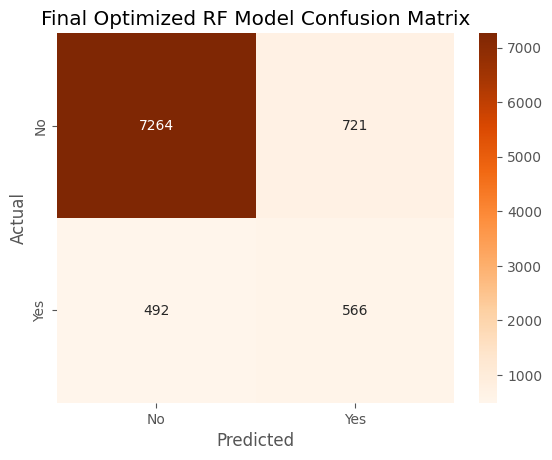

In [8]:
# %%
# --- Hyperparameter Tuning with GridSearchCV for Random Forest ---
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Random Forest
# Note: This grid is smaller for faster execution. You can expand it for a more exhaustive search.
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [5, 10]
}

# 2. Initialize and run the Grid Search
# Using scoring='f1_weighted' as it's a good metric for imbalanced classes
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=2 # Set to 2 to see more details
)

print("Starting Grid Search for the Random Forest model...")
rf_grid_search.fit(X_train, y_train)

# 3. Print the best parameters and score
print(f"\nBest parameters for Random Forest model: {rf_grid_search.best_params_}")
print(f"Best F1-score from Grid Search: {rf_grid_search.best_score_:.4f}")

# --- Evaluate the Best Model Found by Grid Search ---
best_rf_model = rf_grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

print("\n--- Final Optimized Random Forest Model Evaluation ---")
print(classification_report(y_test, y_pred_best_rf, target_names=['No', 'Yes']))

print("\nConfusion Matrix for Optimized Random Forest:")
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Optimized RF Model Confusion Matrix')
plt.show()

Scaling the feature data for K-Means...
Data scaled successfully.

Calculating inertia for the Elbow Method...


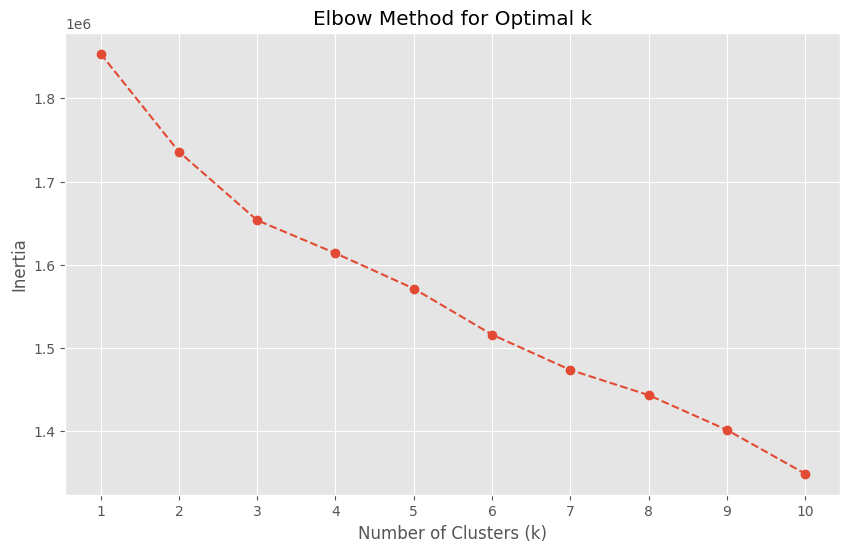

In [9]:
# %%
# --- Imports for K-Means Clustering ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. Scale the Data ---
# K-Means is a distance-based algorithm, so scaling is crucial
print("Scaling the feature data for K-Means...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
print("Data scaled successfully.")


# --- 2. Find the Optimal Number of Clusters (k) using the Elbow Method ---
print("\nCalculating inertia for the Elbow Method...")
inertia = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [12]:
# %%
# --- 3. Applying K-Means with the Chosen k ---
chosen_k = 3 # Replace with the k you identified from the elbow plot
print(f"\nRunning K-Means with k={chosen_k}...")

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to your original cleaned dataframe to analyze them
df_cleaned['cluster'] = cluster_labels
print("K-Means clustering complete. Cluster labels added to the dataframe.")


# --- 4. Analyzing the Clusters ---
# We can now see the distribution of the actual target variable 'y' within each cluster
cluster_analysis = df_cleaned.groupby('cluster')['y'].value_counts(normalize=True).unstack()
cluster_analysis.rename(columns={0: 'No (%)', 1: 'Yes (%)'}, inplace=True)
cluster_analysis = (cluster_analysis * 100).round(2) # Convert to percentage

print("\n--- Cluster Analysis: Distribution of 'Yes'/'No' per Cluster ---")
print(cluster_analysis)

# You can also analyze the size of each cluster
print("\n--- Cluster Sizes ---")
print(df_cleaned['cluster'].value_counts())


Running K-Means with k=3...
K-Means clustering complete. Cluster labels added to the dataframe.

--- Cluster Analysis: Distribution of 'Yes'/'No' per Cluster ---
y        No (%)  Yes (%)
cluster                 
0         88.03    11.97
1         76.91    23.09
2         94.45     5.55

--- Cluster Sizes ---
cluster
0    20967
2    16062
1     8182
Name: count, dtype: int64


In [11]:
# Review 3 final code       

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Train Scaler and K-Means on Training Data ---

print("--- Step 1: Fitting Scaler and K-Means on Training Data ---")
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# Based on your notebook (cell 9), the optimal k is 3
chosen_k = 3

# Train K-Means ONLY on the scaled training data
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
kmeans.fit(X_train_scaled)

# Get cluster labels for the TRAINING data
train_cluster_labels = kmeans.predict(X_train_scaled)

print(f"Scaler fit on X_train.")
print(f"K-Means (k={chosen_k}) trained on X_train_scaled.\n")


# --- 2. Train "Expert" Random Forest Models ---

print("--- Step 2: Training 'Expert' RF Models for each Cluster ---")

# Best RF params from your GridSearchCV in cell 8
rf_params = {
    'n_estimators': 200,
    'max_depth': None,
    'min_samples_leaf': 5,
    'random_state': 42,
    'class_weight': 'balanced',
    'n_jobs': -1
}

# Store expert models in a dictionary
expert_models = {}

for cluster_id in range(chosen_k):
    # 1. Segment the *original* (unscaled) training data based on cluster labels
    # Tree models like Random Forest do not require scaled data.
    cluster_indices = (train_cluster_labels == cluster_id)
    X_train_cluster = X_train[cluster_indices]
    y_train_cluster = y_train[cluster_indices]
    
    print(f"Training model for Cluster {cluster_id} (samples: {len(X_train_cluster)})...")
    
    # 2. Initialize and train the expert model
    expert_rf = RandomForestClassifier(**rf_params)
    expert_rf.fit(X_train_cluster, y_train_cluster)
    
    # 3. Store the trained model
    expert_models[cluster_id] = expert_rf

print("All expert models trained.\n")

--- Step 1: Fitting Scaler and K-Means on Training Data ---
Scaler fit on X_train.
K-Means (k=3) trained on X_train_scaled.

--- Step 2: Training 'Expert' RF Models for each Cluster ---
Training model for Cluster 0 (samples: 25274)...
Training model for Cluster 1 (samples: 10660)...
Training model for Cluster 2 (samples: 234)...
All expert models trained.



--- Step 3: Evaluating the Ensemble Model on the Test Set ---
Ensemble prediction complete.

--- Final K-Means & Random Forest Ensemble Evaluation ---

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.92      0.93      7985
         Yes       0.45      0.52      0.48      1058

    accuracy                           0.87      9043
   macro avg       0.69      0.72      0.70      9043
weighted avg       0.88      0.87      0.87      9043



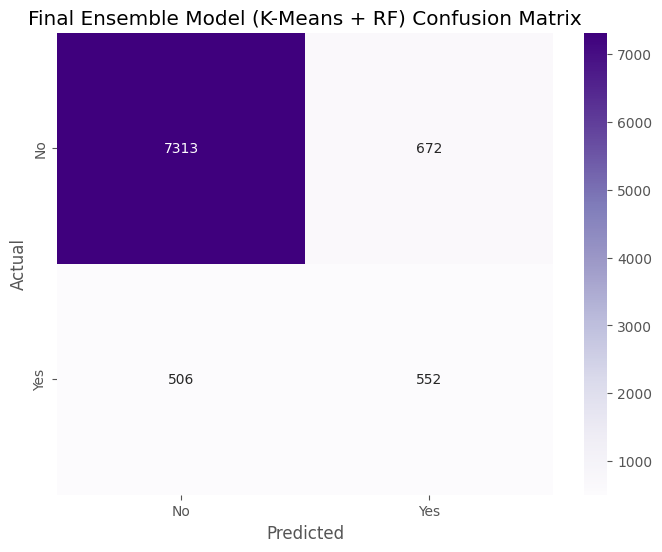

In [14]:
# --- 3. Create the Ensemble Prediction Pipeline for X_test ---

print("--- Step 3: Evaluating the Ensemble Model on the Test Set ---")

# Step A: Get cluster predictions for the TEST set
# First, scale X_test using the scaler fit on X_train
X_test_scaled = scaler.transform(X_test)

# Then, predict clusters using the kmeans model fit on X_train_scaled
test_cluster_labels = kmeans.predict(X_test_scaled)

# Create an array to store the final predictions
y_pred_ensemble = np.zeros_like(y_test)

# Step B: Apply the corresponding expert model for each test sample
for cluster_id in range(chosen_k):
    # 1. Get indices for test samples predicted to be in this cluster
    cluster_indices = (test_cluster_labels == cluster_id)
    
    if cluster_indices.sum() > 0:
        # 2. Get the corresponding expert model
        expert_model = expert_models[cluster_id]
        
        # 3. Get the *original* (unscaled) X_test data for these samples
        X_test_cluster = X_test[cluster_indices]
        
        # 4. Make predictions
        cluster_predictions = expert_model.predict(X_test_cluster)
        
        # 5. Store predictions in the final array
        y_pred_ensemble[cluster_indices] = cluster_predictions

print("Ensemble prediction complete.\n")


# --- 4. Final Evaluation and Conclusion ---

print("--- Final K-Means & Random Forest Ensemble Evaluation ---")

# Generate and print the classification report
report = classification_report(y_test, y_pred_ensemble, target_names=['No', 'Yes'])
print("\nClassification Report:")
print(report)

# Generate and plot the confusion matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Final Ensemble Model (K-Means + RF) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

# 1. Define the models and their prediction variables
models_to_compare = {
    'Optimized CART (Review 1)': y_pred_final,
    'Optimized RF (Review 2)': y_pred_best_rf,
    'K-Means + RF Ensemble (Review 3)': y_pred_ensemble
}

# 2. Create a dictionary to store the results
comparison_results = {
    'Model': [],
    'Accuracy': [],
    'Precision (Yes)': [],
    'Recall (Yes)': [],
    'F1-Score (Yes)': []
}

# 3. Calculate metrics for each model (using pos_label=1 for 'Yes')
for model_name, y_pred in models_to_compare.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    comparison_results['Model'].append(model_name)
    comparison_results['Accuracy'].append(accuracy)
    comparison_results['Precision (Yes)'].append(precision)
    comparison_results['Recall (Yes)'].append(recall)
    comparison_results['F1-Score (Yes)'].append(f1)

# 4. Create and display the comparison DataFrame
df_comparison = pd.DataFrame(comparison_results)
df_comparison = df_comparison.set_index('Model')

print("--- Final Model Comparison Report ---")
print(df_comparison.to_string(float_format='{:.4f}'.format))

--- Final Model Comparison Report ---
                                  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score (Yes)
Model                                                                                    
Optimized CART (Review 1)           0.8206           0.3400        0.5662          0.4248
Optimized RF (Review 2)             0.8659           0.4398        0.5350          0.4827
K-Means + RF Ensemble (Review 3)    0.8697           0.4510        0.5217          0.4838
